<a href="https://colab.research.google.com/github/violet-rgb/ICT_DSA/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction using Machine Learning

## Business Problem
Telecommunication companies face customer loss due to competition and customer dissatisfaction. Customer churn can negatively impact revenue and business growth.

## Project Objective
The objective of this project is to build a machine learning model that predicts whether a customer is likely to churn based on customer demographics, account information, and service usage patterns.

## Importance of Customer Retention
Retaining existing customers is more cost-effective than acquiring new customers. By identifying customers who are likely to churn, telecom companies can take proactive actions such as personalized offers and improved customer support to reduce churn rates.

Import Libraries

In [165]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Loading the Datasets

In this step, we load the training and testing datasets into pandas DataFrames.

Since the training and testing datasets are separate, we will:
1. Add a source column to identify them
2. Combine them into a single dataset
3. Perform preprocessing together
4. Split them back later before model building

This ensures consistent preprocessing and feature engineering across both datasets.

In [166]:
# ==========================================
# Load Training and Testing Datasets
# ==========================================

train = pd.read_csv("Training_data.csv")
test = pd.read_csv("Testing_data.csv")

# Display first 5 rows
print("Training Data:")
display(train.head())

print("\nTesting Data:")
display(test.head())

Training Data:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No



Testing Data:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No



# Adding Source Column

We add a source column to identify whether a row belongs to the training dataset or testing dataset.

This helps us:
- combine datasets safely
- preprocess them together
- split them back correctly later

In [167]:
# ==========================================
# Add Source Column
# ==========================================

train['source'] = 'train'
test['source'] = 'test'

# Check source column
print(train['source'].value_counts())
print(test['source'].value_counts())

source
train    5634
Name: count, dtype: int64
source
test    1409
Name: count, dtype: int64


In [168]:
train

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,source
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No,train
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No,train
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No,train
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No,train
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No,train
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No,train
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No,train
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No,train


# Combining Train and Test Datasets

The train and test datasets are combined into a single dataset using `concat()`.

This ensures:
- consistent preprocessing
- same encoding structure
- identical feature transformations

After preprocessing, the datasets will be separated again for model building.

In [169]:
# ==========================================
# Combine Train and Test Data
# ==========================================

combined_data = pd.concat([train, test], axis=0)

# Reset index
combined_data.reset_index(drop=True, inplace=True)

# Display shape
print("Combined Dataset Shape:", combined_data.shape)

# Display first rows
display(combined_data.head())

Combined Dataset Shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,source
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No,train
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No,train
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No,train
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No,train
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No,train


In [170]:
combined_data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,source
7038,2039-JONDJ,Male,0,No,No,27,Yes,No,DSL,Yes,...,No,No,No,One year,No,Bank transfer (automatic),55.45,1477.65,No,test
7039,2516-VQRRV,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,75.45,158.4,Yes,test
7040,5570-PTWEH,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes,test
7041,1722-LDZJS,Male,0,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.20,1068.15,No,test
7042,5921-NGYRH,Male,0,Yes,No,64,Yes,No,Fiber optic,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,73.55,4764,No,test


Data Understanding / Initial Exploration

# Data Understanding

Before preprocessing the dataset, it is important to understand:
- the structure of the dataset
- data types
- missing values
- duplicates
- statistical summary

This helps identify potential issues and determine appropriate preprocessing techniques.

In [171]:
# ==========================================
# Display First 5 Rows
# ==========================================

combined_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,source
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No,train
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No,train
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No,train
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No,train
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No,train


In [172]:
# ==========================================
# Check Dataset Shape
# ==========================================

print("Shape of Dataset:", combined_data.shape)

Shape of Dataset: (7043, 22)


In [173]:
# ==========================================
# Dataset Information
# ==========================================

combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6874 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    6874 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [174]:
# ==========================================
# Statistical Summary
# ==========================================

combined_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,6649.000000
mean,0.162147,32.371149,64.846902
std,0.368612,24.559481,30.106268
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.650000
50%,0.000000,29.000000,70.400000
75%,0.000000,55.000000,89.900000
max,1.000000,72.000000,118.750000


#Check Duplicate Rows

In [175]:
# ==========================================
# Check Duplicate Rows
# ==========================================

duplicate_count = combined_data.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


Check Missing Values

In [176]:
# ==========================================
# Check Missing Values
# ==========================================

missing_values = combined_data.isnull().sum()

print(missing_values)

customerID            0
gender              169
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity      169
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges      394
TotalCharges        281
Churn                 0
source                0
dtype: int64


#Check Unique Values in Categorical Columns

In [177]:
# ==========================================
# Check Unique Values in Categorical Columns
# ==========================================

categorical_cols = combined_data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(combined_data[col].unique())


Unique values in customerID:
['9509-MPYOD' '7746-AWNQW' '2208-UGTGR' ... '5570-PTWEH' '1722-LDZJS'
 '5921-NGYRH']

Unique values in gender:
['Female' 'Male' nan]

Unique values in Partner:
['No' 'Yes']

Unique values in Dependents:
['No' 'Yes']

Unique values in PhoneService:
['Yes' 'No']

Unique values in MultipleLines:
['No' 'No phone service' 'Yes']

Unique values in InternetService:
['No' 'DSL' 'Fiber optic']

Unique values in OnlineSecurity:
['No internet service' 'No' nan 'Yes']

Unique values in OnlineBackup:
['No internet service' 'No' 'Yes']

Unique values in DeviceProtection:
['No internet service' 'Yes' 'No']

Unique values in TechSupport:
['No internet service' 'Yes' 'No']

Unique values in StreamingTV:
['No internet service' 'No' 'Yes']

Unique values in StreamingMovies:
['No internet service' 'No' 'Yes']

Unique values in Contract:
['One year' 'Month-to-month' 'Two year']

Unique values in PaperlessBilling:
['No' 'Yes']

Unique values in PaymentMethod:
['Mailed check' 'E

#Data Cleaning

# Data Cleaning

Data cleaning is an essential preprocessing step in machine learning.

In this step, we will:
- correct incorrect data types
- handle missing values
- prepare the dataset for analysis and modeling

Proper data cleaning improves model performance and ensures reliable results.

In [178]:
# ==========================================
# Check Data Types
# ==========================================

combined_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


# Converting TotalCharges to Numeric

The `TotalCharges` column is stored as an object datatype instead of numeric format.

Since machine learning models require numerical data for calculations, the column is converted into numeric format using `pd.to_numeric()`.

Errors are converted into missing values (`NaN`) using `errors='coerce'`.

In [179]:
# ==========================================
# Convert TotalCharges to Numeric
# ==========================================

combined_data['TotalCharges'] = pd.to_numeric(
    combined_data['TotalCharges'],
    errors='coerce'
)

# Check datatype again
print(combined_data['TotalCharges'].dtype)

float64


In [180]:
# ==========================================
# Check Missing Values Again
# ==========================================

combined_data.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [181]:
# ==========================================
# Separate Numerical and Categorical Columns
# ==========================================

numerical_cols = combined_data.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = combined_data.select_dtypes(
    include='object'
).columns

print("Numerical Columns:\n", numerical_cols)
print("\nCategorical Columns:\n", categorical_cols)

Numerical Columns:
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Columns:
 Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'source'],
      dtype='object')


In [182]:
# ==========================================
# Fill Missing Values
# ==========================================

# Fill numerical columns with median
for col in numerical_cols:
    combined_data[col].fillna(
        combined_data[col].median(),
        inplace=True
    )

# Fill categorical columns with mode
for col in categorical_cols:
    combined_data[col].fillna(
        combined_data[col].mode()[0],
        inplace=True
    )

# Check missing values again
combined_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Exploratory Data Analysis (EDA)

EDA helps understand customer behavior, identify patterns, and discover relationships between features and customer churn.

Visualizations are used to gain business insights and support data-driven decision making.

## Churn Distribution

This visualization shows the distribution of customers who stayed and customers who churned.

Understanding class distribution is important because highly imbalanced data can affect model performance.

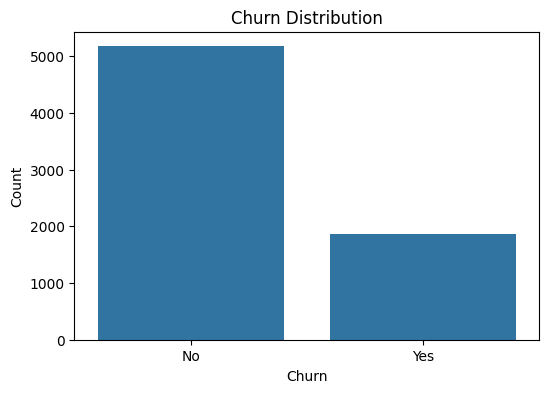

In [183]:
# ==========================================
# Churn Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=combined_data
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Business Insight

The dataset contains more non-churn customers than churn customers, indicating class imbalance.

This suggests that most customers continue using the telecom service, while a smaller proportion discontinue the service.

## Distribution of Numerical Features

Histograms are used to analyze the distribution of numerical variables such as tenure, monthly charges, and total charges.

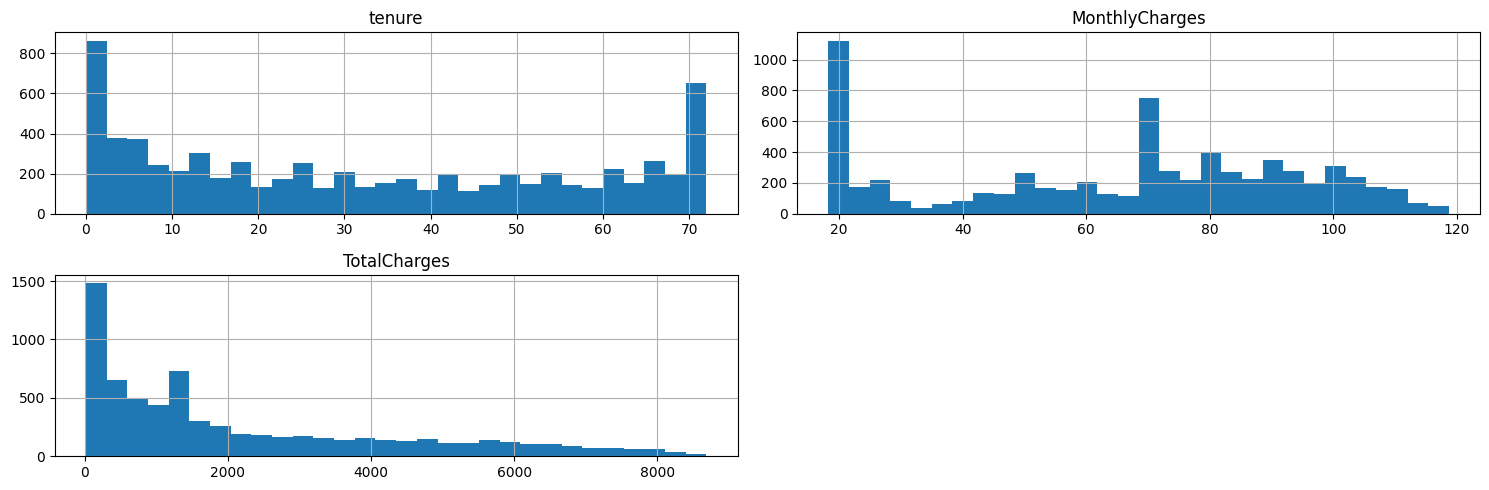

In [184]:
# ==========================================
# Histograms for Numerical Columns
# ==========================================

numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

combined_data[numerical_features].hist(
    figsize=(15,5),
    bins=30
)

plt.tight_layout()
plt.show()

### Business Insights

- Many customers have lower tenure, indicating a large number of relatively new customers.
- Monthly charges vary significantly, suggesting different subscription plans and service usage.
- Total charges are positively skewed, indicating that some long-term customers contribute higher revenue.

## Categorical Features vs Churn

Countplots help analyze the relationship between categorical variables and customer churn.

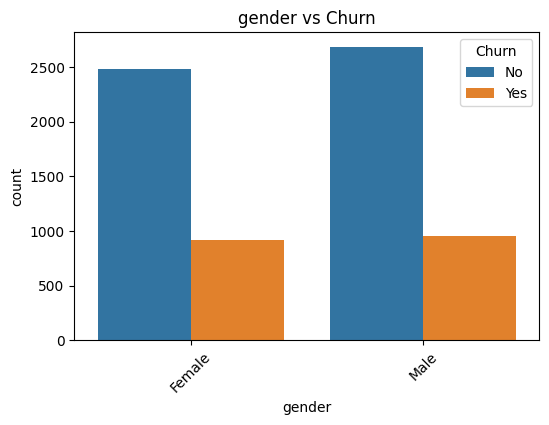

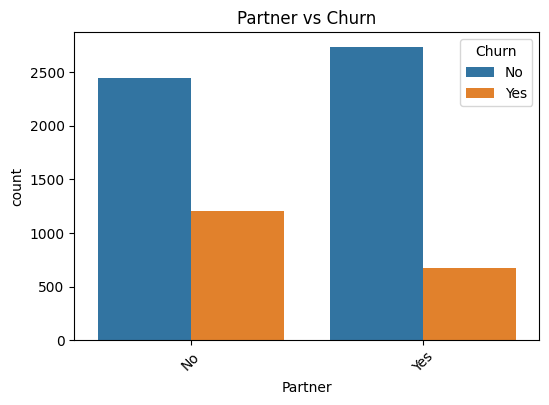

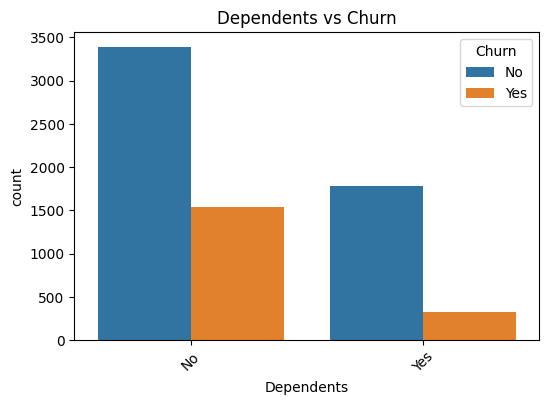

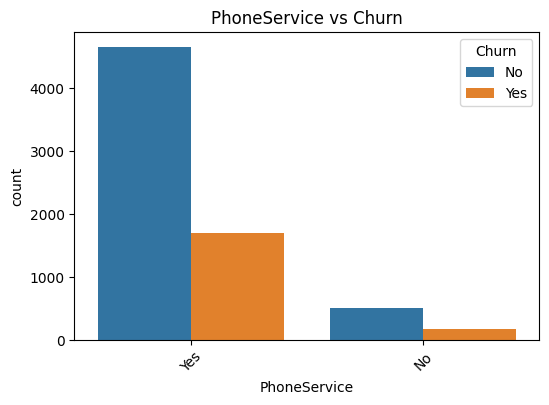

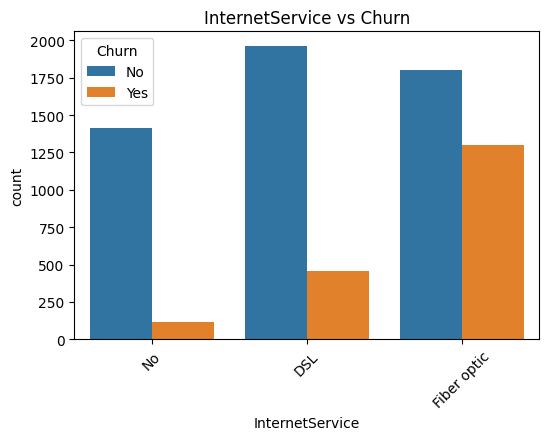

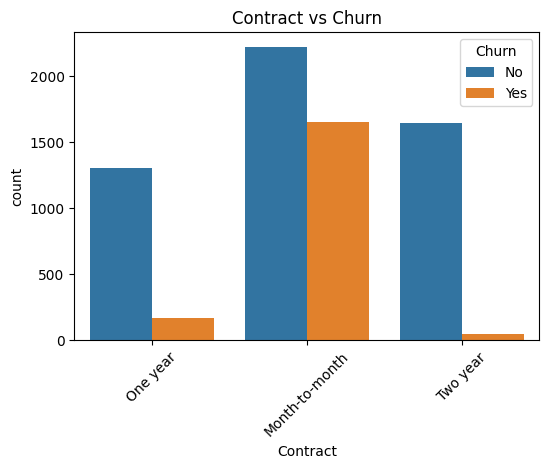

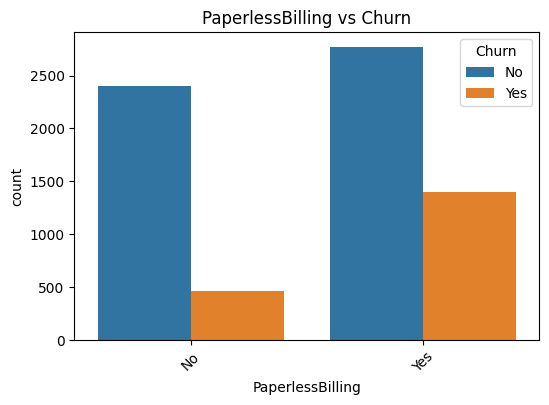

In [185]:
# ==========================================
# Countplots for Categorical Features
# ==========================================

categorical_features = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'InternetService',
    'Contract',
    'PaperlessBilling'
]

for col in categorical_features:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        hue='Churn',
        data=combined_data
    )

    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)

    plt.show()

## Correlation Heatmap

A correlation heatmap is used to measure relationships between numerical variables.

Correlation values range from:
- -1 → strong negative relationship
- 0 → no relationship
- +1 → strong positive relationship

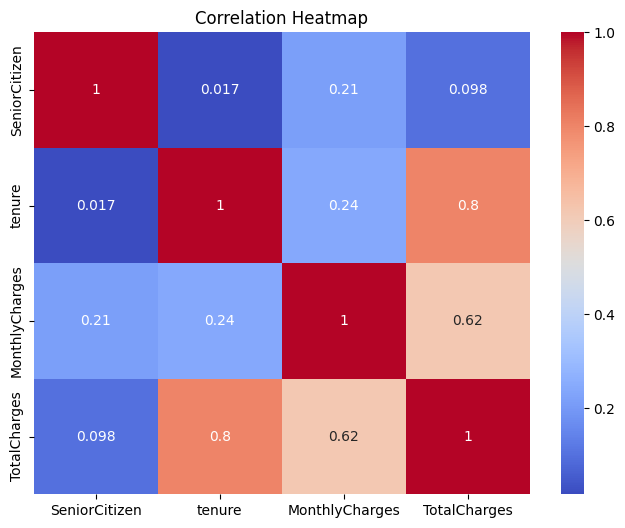

In [186]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    combined_data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Outlier Detection and Handling

Outliers are extreme values that differ significantly from other observations.

Outlier detection is important because extreme values can negatively impact machine learning model performance and statistical analysis.

Boxplots are used to visually identify potential outliers in numerical columns.

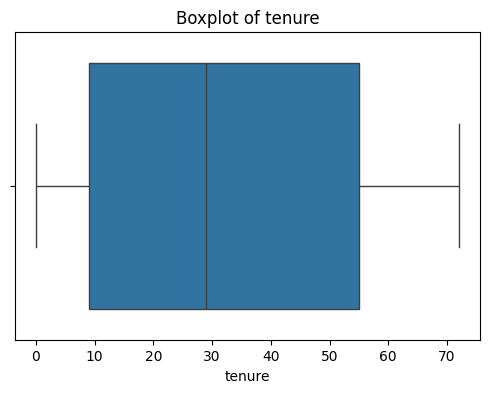

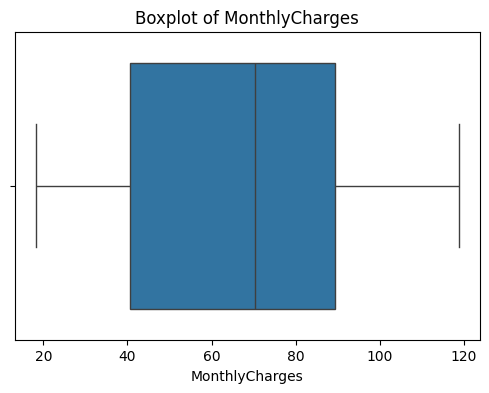

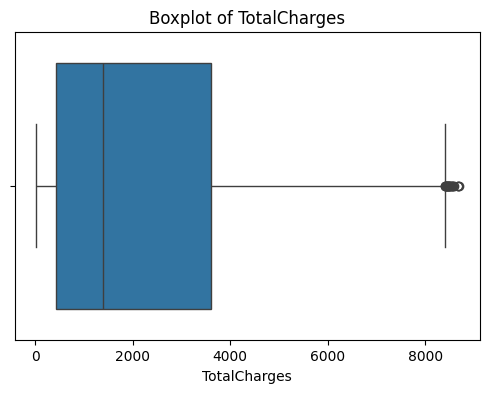

In [187]:
# ==========================================
# Boxplots for Numerical Features
# ==========================================

numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

for col in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=combined_data[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

## Outlier Handling using IQR Method

The IQR method is used to detect outliers.

Instead of removing outliers, capping is performed to limit extreme values within acceptable boundaries.

This approach preserves important customer information while reducing the influence of extreme values.

In [188]:
# ==========================================
# Outlier Capping using IQR Method
# ==========================================

for col in numerical_features:

    # Calculate Q1 and Q3
    Q1 = combined_data[col].quantile(0.25)
    Q3 = combined_data[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping
    combined_data[col] = np.where(
        combined_data[col] < lower_bound,
        lower_bound,
        combined_data[col]
    )

    combined_data[col] = np.where(
        combined_data[col] > upper_bound,
        upper_bound,
        combined_data[col]
    )

print("Outlier capping completed.")

Outlier capping completed.


after outlier

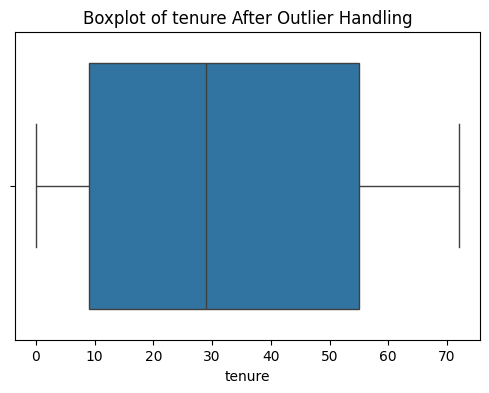

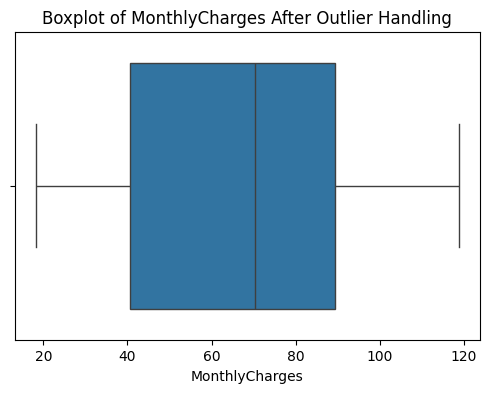

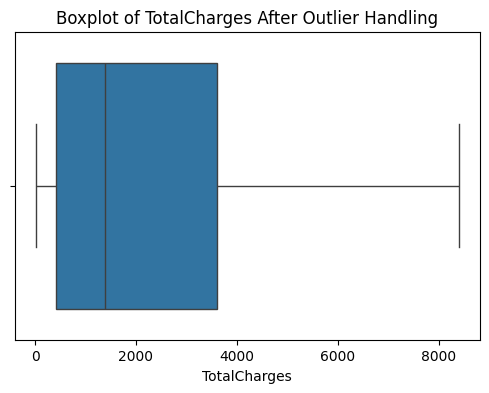

In [189]:
# ==========================================
# Boxplots After Outlier Handling
# ==========================================

for col in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=combined_data[col]
    )

    plt.title(f"Boxplot of {col} After Outlier Handling")

    plt.show()

### Business Insight

Outlier treatment was performed using the IQR method to reduce the impact of extreme numerical values while preserving customer information.

Capping was preferred over row removal to avoid unnecessary data loss.

# Feature Engineering

Feature engineering involves creating new features from existing variables to improve machine learning model performance.

New features are created to capture customer behavior, spending patterns, and service relationships more effectively.

## Customer Lifetime Value (CLV)

Customer Lifetime Value is estimated by multiplying customer tenure with monthly charges.

This feature helps represent the overall monetary value contributed by a customer over time.

In [190]:
# ==========================================
# Customer Lifetime Value
# ==========================================

combined_data['CLV'] = (
    combined_data['tenure'] *
    combined_data['MonthlyCharges']
)

combined_data[['tenure', 'MonthlyCharges', 'CLV']].head()

,tenure,MonthlyCharges,CLV
0,35.0,20.75,726.25
1,28.0,35.75,1001.00
2,56.0,98.60,5521.60
3,39.0,20.45,797.55
4,43.0,51.25,2203.75


## Tenure Groups

Customers are grouped based on tenure duration to better analyze customer lifecycle stages such as new, mid-term, and long-term customers.

In [191]:
# ==========================================
# Create Tenure Groups
# ==========================================

def tenure_group(tenure):

    if tenure <= 12:
        return '0-12 Months'

    elif tenure <= 24:
        return '12-24 Months'

    elif tenure <= 48:
        return '24-48 Months'

    else:
        return '48+ Months'

# Apply function
combined_data['TenureGroup'] = combined_data['tenure'].apply(tenure_group)

# Check values
combined_data['TenureGroup'].value_counts()

,count
TenureGroup,
48+ Months,2239
0-12 Months,2186
24-48 Months,1594
12-24 Months,1024


## Contract and Tenure Interaction Feature

An interaction feature is created by combining contract type and tenure group.

This helps capture combined customer behavior patterns that may influence churn.

In [192]:
# ==========================================
# Contract + Tenure Interaction Feature
# ==========================================

combined_data['Contract_Tenure'] = (
    combined_data['Contract'] +
    "_" +
    combined_data['TenureGroup']
)

# Display sample values
combined_data[['Contract', 'TenureGroup', 'Contract_Tenure']].head()

,Contract,TenureGroup,Contract_Tenure
0,One year,24-48 Months,One year_24-48 Months
1,Month-to-month,24-48 Months,Month-to-month_24-48 Months
2,Month-to-month,48+ Months,Month-to-month_48+ Months
3,Two year,24-48 Months,Two year_24-48 Months
4,One year,24-48 Months,One year_24-48 Months


## Dropping CustomerID Column

The customerID column is removed because it acts only as a unique identifier and does not contribute meaningful predictive information for churn prediction.

Keeping unique identifiers may lead to unnecessary feature expansion during encoding and negatively affect model performance.

In [193]:
# ==========================================
# Drop CustomerID Column
# ==========================================

combined_data.drop('customerID', axis=1, inplace=True)

print("customerID column removed successfully.")

customerID column removed successfully.


#Encoding

# Encoding Categorical Variables

Machine learning models cannot process categorical text values directly.

One Hot Encoding is used to convert categorical variables into numerical format.

One Hot Encoding is preferred over Label Encoding for nominal data because it avoids introducing artificial ordinal relationships between categories.

The parameter `drop_first=True` is used to reduce multicollinearity by removing one redundant category from each encoded feature.

In [194]:
# ==========================================
# One Hot Encoding
# ==========================================

combined_data = pd.get_dummies(
    combined_data,
    drop_first=True
)

# Display first rows
combined_data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CLV,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Tenure_Month-to-month_24-48 Months,Contract_Tenure_Month-to-month_48+ Months,Contract_Tenure_One year_0-12 Months,Contract_Tenure_One year_12-24 Months,Contract_Tenure_One year_24-48 Months,Contract_Tenure_One year_48+ Months,Contract_Tenure_Two year_0-12 Months,Contract_Tenure_Two year_12-24 Months,Contract_Tenure_Two year_24-48 Months,Contract_Tenure_Two year_48+ Months
0,0,35.0,20.75,700.45,726.25,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
1,0,28.0,35.75,961.40,1001.00,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
2,0,56.0,98.60,5581.05,5521.60,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
3,0,39.0,20.45,790.00,797.55,True,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,0,43.0,51.25,2151.60,2203.75,False,True,True,False,True,...,False,False,False,False,True,False,False,False,False,False


In [195]:
# ==========================================
# Dataset Shape After Encoding
# ==========================================

print("Shape After Encoding:", combined_data.shape)

Shape After Encoding: (7043, 47)


In [196]:
# ==========================================
# Display Column Names
# ==========================================

combined_data.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'CLV',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes', 'source_train', 'TenureGroup_12-24 Months',
       'TenureGroup_24-48 Months', 'TenureGroup_48+ Months',
       'Contract_Te

Feature Scaling

# Feature Scaling

Feature scaling is performed to bring numerical variables to a similar scale.

Machine learning algorithms such as Logistic Regression, KNN, and SVM are sensitive to differences in feature magnitudes.

StandardScaler is used because it standardizes features around zero mean and unit variance and performs well in the presence of moderate outliers.

In [197]:
# ==========================================
# Separate Features and Target
# ==========================================

X = combined_data.drop('Churn_Yes', axis=1)

y = combined_data['Churn_Yes']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 46)
Target Shape: (7043,)


In [198]:
# ==========================================
# Apply StandardScaler
# ==========================================

# Columns to scale
scale_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'CLV'
]

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
X[scale_cols] = scaler.fit_transform(X[scale_cols])

# Display first rows
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CLV,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Tenure_Month-to-month_24-48 Months,Contract_Tenure_Month-to-month_48+ Months,Contract_Tenure_One year_0-12 Months,Contract_Tenure_One year_12-24 Months,Contract_Tenure_One year_24-48 Months,Contract_Tenure_One year_48+ Months,Contract_Tenure_Two year_0-12 Months,Contract_Tenure_Two year_12-24 Months,Contract_Tenure_Two year_24-48 Months,Contract_Tenure_Two year_48+ Months
0,0,0.107048,-1.516772,-0.690097,-0.694492,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
1,0,-0.177995,-1.004436,-0.572575,-0.571933,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
2,0,0.962175,1.142251,1.507954,1.444600,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
3,0,0.269929,-1.527019,-0.649767,-0.662687,True,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,0,0.432811,-0.475023,-0.036550,-0.035415,False,True,True,False,True,...,False,False,False,False,True,False,False,False,False,False


# Model Building

Machine learning models are trained to predict customer churn based on customer demographics, services, and billing information.

Multiple classification algorithms are used to compare performance and identify the best-performing model.

## Logistic Regression

Logistic Regression is a supervised machine learning classification algorithm used to predict binary outcomes such as churn (Yes/No).

It estimates the probability of customer churn based on input features.

# Train-Test Split

The dataset is divided into training and testing subsets using `train_test_split()`.

The training set is used to train machine learning models, while the testing set is used to evaluate model performance on unseen data.

In [202]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (5634, 46)
X_test Shape: (1409, 46)
y_train Shape: (5634,)
y_test Shape: (1409,)


In [203]:
# ==========================================
# Logistic Regression Model
# ==========================================

# Initialize model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


## Logistic Regression Evaluation

The performance of Logistic Regression is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

In [204]:
# ==========================================
# Logistic Regression Evaluation
# ==========================================

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

# Precision
log_precision = precision_score(y_test, y_pred_log)

# Recall
log_recall = recall_score(y_test, y_pred_log)

# F1 Score
log_f1 = f1_score(y_test, y_pred_log)

# Print metrics
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Accuracy : 0.8119233498935415
Precision: 0.6822742474916388
Recall   : 0.5454545454545454
F1 Score : 0.6062407132243685


Confusion Matrix

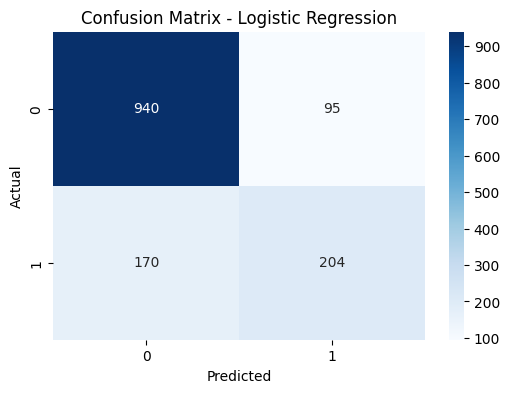

In [205]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [206]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

       False       0.85      0.91      0.88      1035
        True       0.68      0.55      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm that creates decision rules based on feature values to classify customers into churn and non-churn categories.

In [207]:
# ==========================================
# Decision Tree Model
# ==========================================

# Initialize model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [208]:
# ==========================================
# Decision Tree Evaluation
# ==========================================

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(y_test, y_pred_dt)

dt_recall = recall_score(y_test, y_pred_dt)

dt_f1 = f1_score(y_test, y_pred_dt)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.7331440738112136
Precision: 0.49744897959183676
Recall   : 0.5213903743315508
F1 Score : 0.5091383812010444


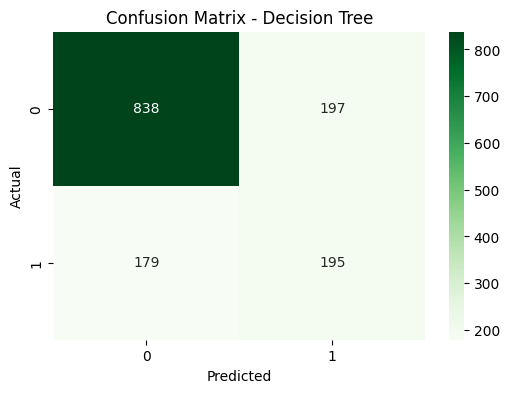

In [209]:
# ==========================================
# Confusion Matrix
# ==========================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [210]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       False       0.82      0.81      0.82      1035
        True       0.50      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.73      0.74      1409



## Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

The final prediction is determined using majority voting across multiple trees.

In [211]:
# ==========================================
# Random Forest Model
# ==========================================

# Initialize model
rf_model = RandomForestClassifier(
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [212]:
# ==========================================
# Random Forest Evaluation
# ==========================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.7977288857345636
Precision: 0.6430868167202572
Recall   : 0.5347593582887701
F1 Score : 0.583941605839416


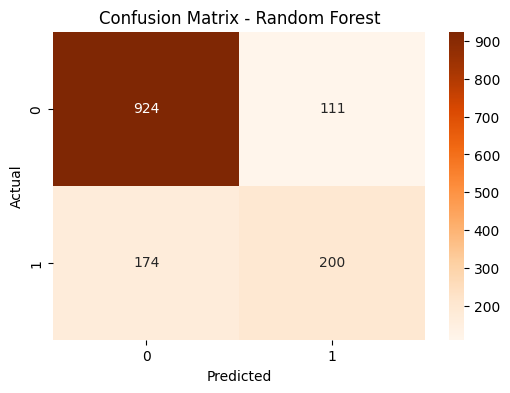

In [213]:
# ==========================================
# Confusion Matrix
# ==========================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [214]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.84      0.89      0.87      1035
        True       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Support Vector Machine (SVM)

Support Vector Machine is a supervised machine learning classification algorithm that identifies the optimal boundary (hyperplane) to separate classes.

SVM aims to maximize the margin between churn and non-churn customers for better generalization.

In [215]:
# ==========================================
# Support Vector Machine Model
# ==========================================

# Initialize model
svm_model = SVC()

# Train model
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


In [216]:
# ==========================================
# SVM Evaluation
# ==========================================

svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(y_test, y_pred_svm)

svm_recall = recall_score(y_test, y_pred_svm)

svm_f1 = f1_score(y_test, y_pred_svm)

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.7963094393186657
Precision: 0.667953667953668
Recall   : 0.4625668449197861
F1 Score : 0.5466034755134281


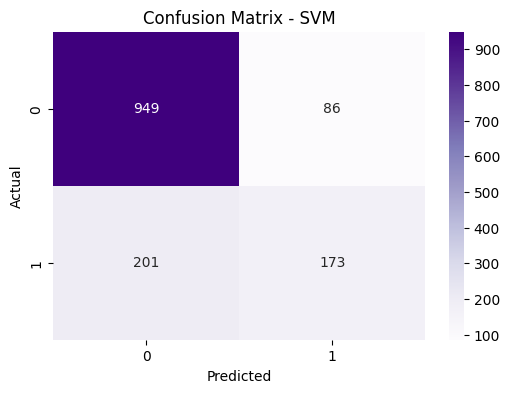

In [217]:
# ==========================================
# Confusion Matrix
# ==========================================

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [218]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

       False       0.83      0.92      0.87      1035
        True       0.67      0.46      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



## Naive Bayes Classifier

Naive Bayes is a probabilistic machine learning algorithm based on Bayes Theorem.

It predicts customer churn probabilities while assuming that input features are independent from each other.

In [219]:
# ==========================================
# Naive Bayes Model
# ==========================================

# Initialize model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Model Trained Successfully")

Naive Bayes Model Trained Successfully


In [220]:
# ==========================================
# Naive Bayes Evaluation
# ==========================================

nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_precision = precision_score(y_test, y_pred_nb)

nb_recall = recall_score(y_test, y_pred_nb)

nb_f1 = f1_score(y_test, y_pred_nb)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 0.6018452803406671
Precision: 0.3914053426248548
Recall   : 0.9010695187165776
F1 Score : 0.545748987854251


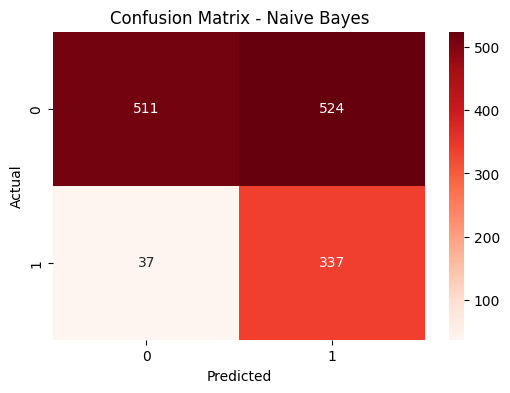

In [221]:
# ==========================================
# Confusion Matrix
# ==========================================

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [222]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

       False       0.93      0.49      0.65      1035
        True       0.39      0.90      0.55       374

    accuracy                           0.60      1409
   macro avg       0.66      0.70      0.60      1409
weighted avg       0.79      0.60      0.62      1409



## K-Nearest Neighbors (KNN)

KNN is a distance-based supervised machine learning algorithm that classifies customers based on similarities with nearby data points.

The algorithm predicts churn by analyzing the nearest neighboring customers.

In [223]:
# ==========================================
# KNN Model
# ==========================================

# Initialize model
knn_model = KNeighborsClassifier()

# Train model
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [224]:
# ==========================================
# KNN Evaluation
# ==========================================

knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(y_test, y_pred_knn)

knn_recall = recall_score(y_test, y_pred_knn)

knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

Accuracy : 0.7849538679914834
Precision: 0.5931758530183727
Recall   : 0.6042780748663101
F1 Score : 0.5986754966887418


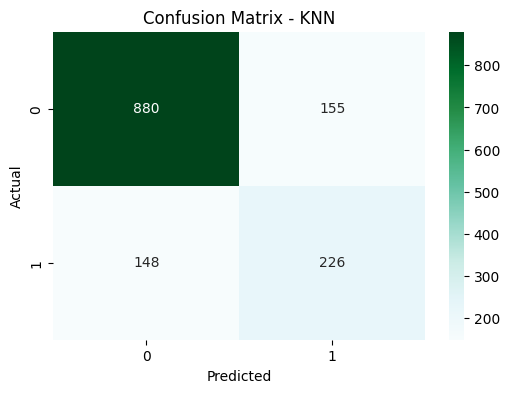

In [225]:
# ==========================================
# Confusion Matrix
# ==========================================

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='BuGn'
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [226]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       False       0.86      0.85      0.85      1035
        True       0.59      0.60      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.79      1409



# Model Comparison

In [227]:
# ==========================================
# Model Comparison Table
# ==========================================

model_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'Naive Bayes',
        'KNN'
    ],

    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        nb_accuracy,
        knn_accuracy
    ],

    'Precision': [
        log_precision,
        dt_precision,
        rf_precision,
        svm_precision,
        nb_precision,
        knn_precision
    ],

    'Recall': [
        log_recall,
        dt_recall,
        rf_recall,
        svm_recall,
        nb_recall,
        knn_recall
    ],

    'F1 Score': [
        log_f1,
        dt_f1,
        rf_f1,
        svm_f1,
        nb_f1,
        knn_f1
    ]
})

# Display comparison table
model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.811923,0.682274,0.545455,0.606241
1,Decision Tree,0.733144,0.497449,0.521390,0.509138
2,Random Forest,0.797729,0.643087,0.534759,0.583942
3,SVM,0.796309,0.667954,0.462567,0.546603
4,Naive Bayes,0.601845,0.391405,0.901070,0.545749
5,KNN,0.784954,0.593176,0.604278,0.598675


In [228]:
#F1-score is often a balanced metric for classification problems.
# ==========================================
# Sort Models by F1 Score
# ==========================================

model_results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.811923,0.682274,0.545455,0.606241
5,KNN,0.784954,0.593176,0.604278,0.598675
2,Random Forest,0.797729,0.643087,0.534759,0.583942
3,SVM,0.796309,0.667954,0.462567,0.546603
4,Naive Bayes,0.601845,0.391405,0.901070,0.545749
1,Decision Tree,0.733144,0.497449,0.521390,0.509138


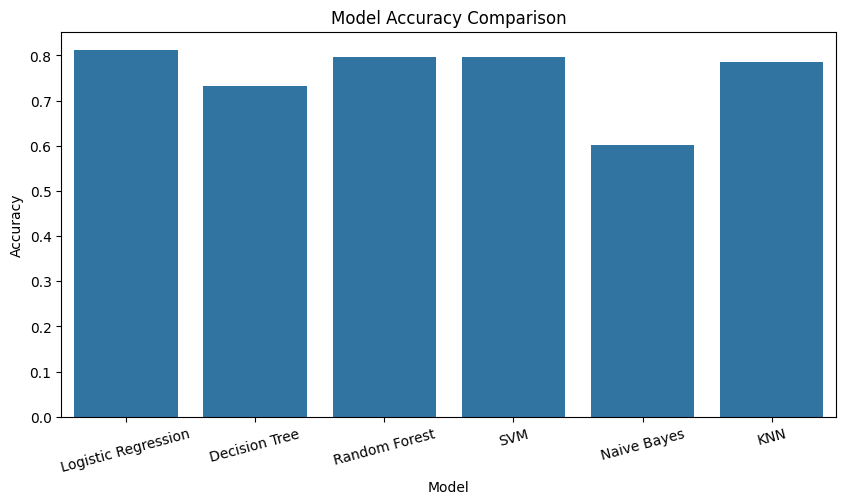

In [229]:
# ==========================================
# Model Accuracy Comparison
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

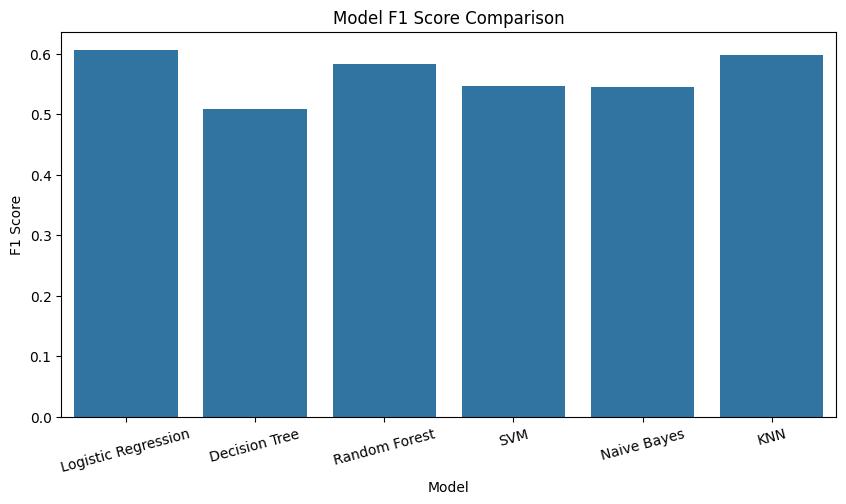

In [230]:
# ==========================================
# Model F1 Score Comparison
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=model_results
)

plt.title("Model F1 Score Comparison")

plt.xticks(rotation=15)

plt.show()

# Hyperparameter Tuning

Hyperparameter tuning is performed to optimize model performance by selecting the best parameter combinations.

GridSearchCV is used to systematically evaluate multiple hyperparameter combinations using cross-validation.

In [231]:
# ==========================================
# Hyperparameter Grid
# ==========================================

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

In [232]:
# ==========================================
# GridSearchCV
# ==========================================

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring='f1',

    n_jobs=-1,

    verbose=1
)

# Train GridSearchCV
grid_search.fit(X_train, y_train)

print("GridSearchCV Completed")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV Completed


In [233]:
# ==========================================
# Best Parameters
# ==========================================

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [234]:
# ==========================================
# Best Cross Validation Score
# ==========================================

print("Best F1 Score:")
print(grid_search.best_score_)

Best F1 Score:
0.5695154188262578


In [235]:
# ==========================================
# Best Tuned Model
# ==========================================

best_rf_model = grid_search.best_estimator_

# Predictions
y_pred_tuned = best_rf_model.predict(X_test)

# Metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

tuned_precision = precision_score(y_test, y_pred_tuned)

tuned_recall = recall_score(y_test, y_pred_tuned)

tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Accuracy : 0.8062455642299503
Precision: 0.6810035842293907
Recall   : 0.5080213903743316
F1 Score : 0.5819295558958653


### Hyperparameter Tuning Insights

GridSearchCV improved model optimization by identifying the best parameter combinations for Random Forest.

Cross-validation ensured more reliable performance estimation and reduced the risk of overfitting.

# Feature Importance Analysis

Feature importance analysis helps identify which customer attributes contribute most to churn prediction.

Understanding important features provides valuable business insights for improving customer retention strategies.

In [236]:
# ==========================================
# Feature Importance
# ==========================================

# Extract feature importance
importance = best_rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top features
feature_importance.head(10)

,Feature,Importance
1,tenure,0.124416
3,TotalCharges,0.114671
4,CLV,0.113279
2,MonthlyCharges,0.086394
11,InternetService_Fiber optic,0.075819
29,PaymentMethod_Electronic check,0.053307
26,Contract_Two year,0.042655
34,TenureGroup_48+ Months,0.027589
14,OnlineSecurity_Yes,0.022673
45,Contract_Tenure_Two year_48+ Months,0.020241


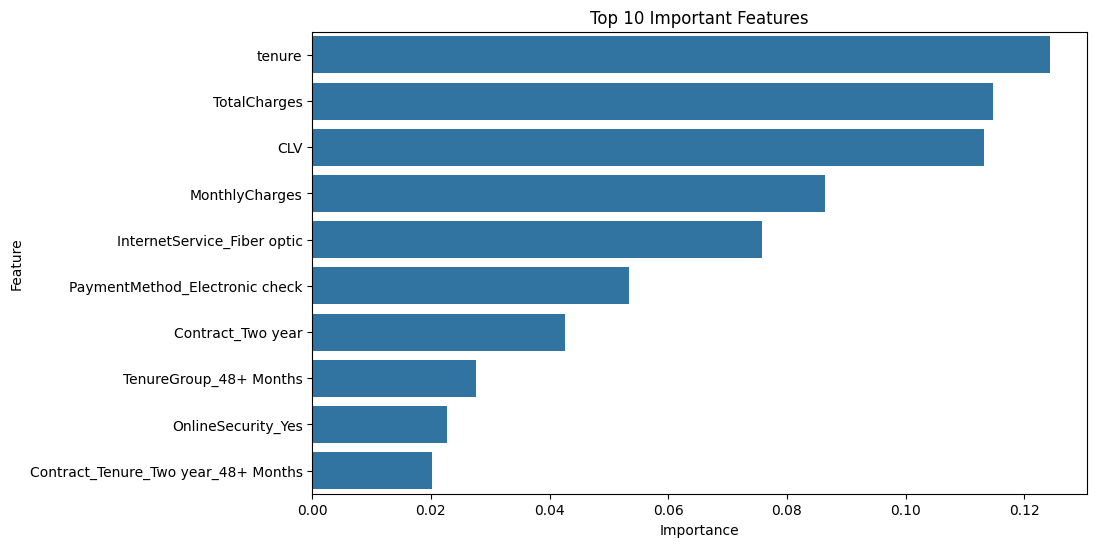

In [238]:
# ==========================================
# Top 10 Important Features
# ==========================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

### Feature Importance Insights

- Customers with shorter tenure showed higher churn tendency.
- Monthly charges significantly influenced churn behavior.
- Contract type played a major role in customer retention.
- Customers using fiber optic internet services showed increased churn probability.
- Additional support services such as TechSupport and OnlineSecurity contributed to customer retention.